# **Pertemuan 3: Aplikasi Interaktif: Kode QR, Landmark, dan Image Overlay**

**Tujuan Sesi:**  
Peserta mengintegrasikan semua pengetahuan untuk membangun aplikasi interaktif. Konsep overlay akan diperkenalkan secara *"just-in-time"* sebagai bagian dari proyek akhir.


<!-- ## **Pengantar: Bagaimana QR Bekerja?**
### **Teori: Anatomi Dasar Kode QR dan Cara Kerjanya**

**Kode QR (Quick Response)** adalah jenis barcode 2D yang dapat menyimpan berbagai jenis data seperti:
- URL website
- Teks biasa
- Informasi kontak
- Koordinat GPS

**Struktur Kode QR:**
1. **Finder Patterns**: Tiga kotak besar di sudut yang membantu scanner mengenali orientasi QR
2. **Timing Patterns**: Garis hitam-putih bergantian untuk menentukan koordinat modul
3. **Alignment Patterns**: Kotak kecil untuk koreksi distorsi
4. **Format Information**: Area yang berisi informasi tentang error correction level
5. **Data Area**: Area yang berisi data aktual yang dikodekan
6. **Quiet Zone**: Margin kosong di luar QR yang penting agar scanner bisa memisahkan QR dari latar.
7. **Version Information / Dark Module** — pada versi besar ada area yang menyimpan nomor versi, dan ada modul statis kecil yang juga berfungsi sebagai referensi. -->

## **Membuat Pembaca QR Code**

Sekarang, kita akan memanfaatkan library `pyzbar` dan `cv2.QRCodeDetector` untuk menemukan dan membaca QR Code

In [2]:
# Import library yang dibutuhkan
import numpy as np  # Untuk operasi numerik dan manipulasi array
import matplotlib.pyplot as plt  # Untuk visualisasi gambar
import cv2  # OpenCV: library utama untuk pengolahan citra dan aplikasi terkait
import os  # Untuk operasi file dan path
import pyzbar  # Deteksi QR Code
from pyzbar.pyzbar import decode
import dlib

# Cek versi library yang diinstal
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print("Versi pyzbar:", pyzbar.__file__)
print("Versi dlib:", dlib.__file__)

Versi numpy: 1.23.5
Versi matplotlib: 3.9.2
Versi OpenCV: 4.12.0
Versi pyzbar: c:\Users\hp\multimedia\.venv\lib\site-packages\pyzbar\__init__.py
Versi dlib: c:\Users\hp\multimedia\.venv\lib\site-packages\dlib\__init__.py


### ⚠️ **Perhatian: Instalasi `pyzbar` di Windows**

Beberapa pengguna Windows mungkin mengalami error saat menginstal **`pyzbar`**, karena library ini bergantung pada **ZBar** dan **Visual C++ Runtime**.

🧩 **Langkah Instalasi Aman (Windows & Python 3.7–3.10)**

1. Pastikan kamu menggunakan **Python 3.7–3.10 (64-bit)**.

   > Cek versi dengan:

   ```bash
   python --version
   ```
2. Instal `pyzbar` versi stabil:

   ```bash
   pip install pyzbar==0.1.9
   ```
3. Jika muncul error `ImportError` atau gagal saat `import pyzbar`, unduh dan pasang:

   * **[Microsoft Visual C++ Redistributable for Visual Studio 2013 (vcredist_x64.exe)](https://www.microsoft.com/en-us/download/details.aspx?id=40784)**
     *(Gunakan `vcredist_x86.exe` jika memakai Python 32-bit)*
4. Setelah itu, ulangi:

   ```bash
   pip install pyzbar
   ```
5. Coba jalankan pengujian sederhana:

   ```python
   from pyzbar.pyzbar import decode
   import cv2
   print(decode(cv2.imread('data/qr1.png')))
   ```

💡 **Catatan:**

* Di Windows, file **DLL ZBar** sudah termasuk di dalam wheel `pyzbar`, jadi **tidak perlu install `zbar` manual**.
* Untuk **macOS** dan **Linux**, kamu wajib install pustaka `zbar` terlebih dahulu:

  ```bash
  # macOS
  brew install zbar

  # Linux (Ubuntu/Debian)
  sudo apt-get install libzbar0
  ```


### **Memuat Gambar QR Code**

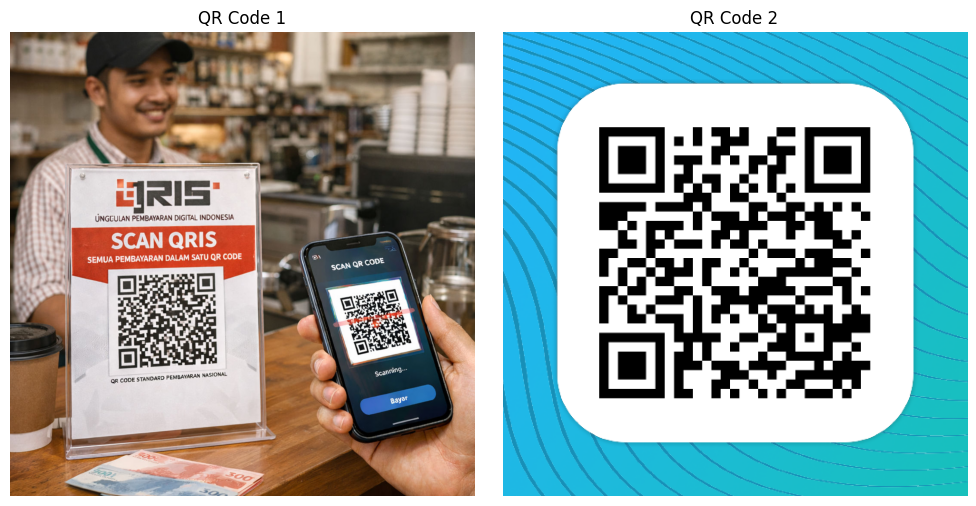

In [2]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Path ke folder data dan file gambar (Sekarang 'os' sudah aman digunakan)
image_path1 = os.path.join("data", "qr3.jpg")
image_path2 = os.path.join("data", "qr4.png")

# 2. Membaca gambar menggunakan OpenCV
image1 = cv2.imread(image_path1)
image2 = cv2.imread(image_path2)

# Validasi Keamanan: Jaga-jaga jika file QR code tidak ditemukan di folder 'data'
if image1 is None:
    raise FileNotFoundError(
        f"Gagal membaca gambar 1! File tidak ditemukan di lokasi: {image_path1}"
    )
if image2 is None:
    raise FileNotFoundError(
        f"Gagal membaca gambar 2! File tidak ditemukan di lokasi: {image_path2}"
    )

# 3. Plot kedua gambar berdampingan
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
axes[0].set_title("QR Code 1")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
axes[1].set_title("QR Code 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **Membaca QR Code**

=== HASIL DETEKSI QR CODE (OPENCV) ===
Isi Data Teks QR: https://freeqrscanner.page.link/naxz
Titik Koordinat Sudut:
[[[106. 106.]
  [404. 106.]
  [404. 404.]
  [106. 404.]]]



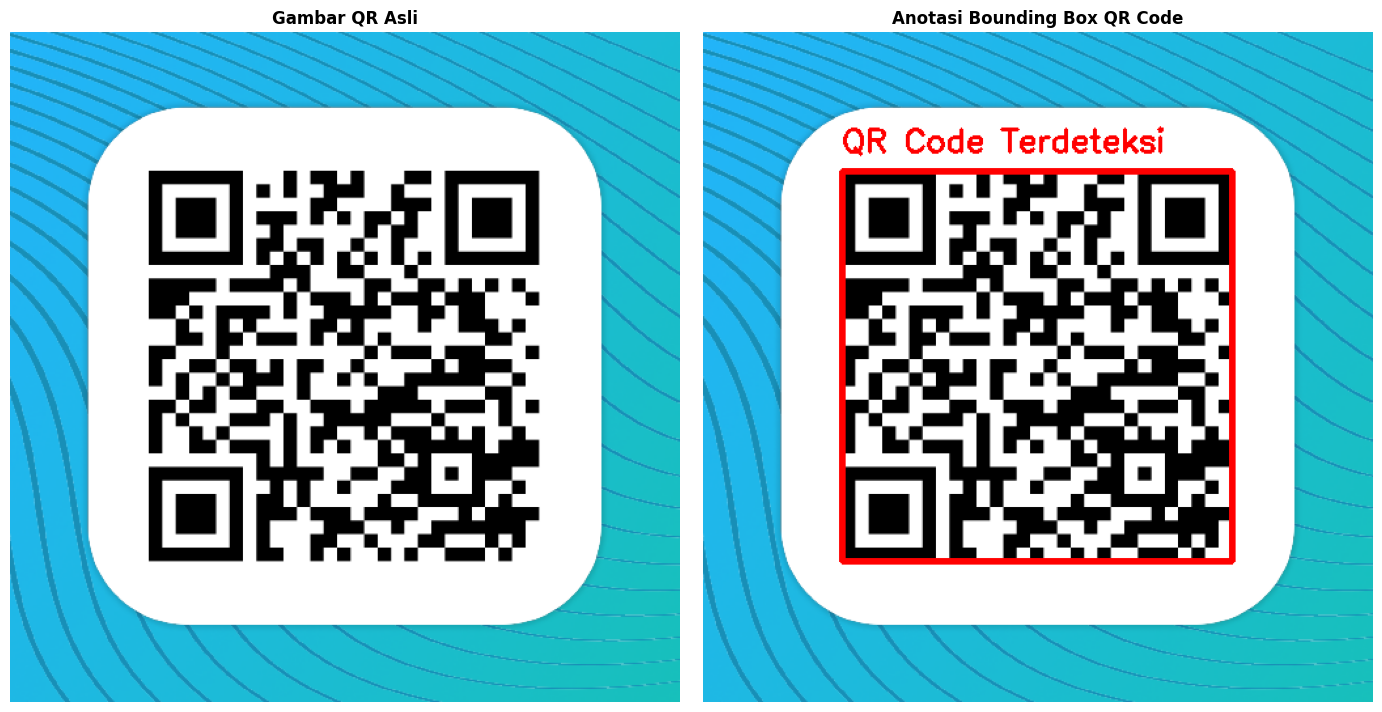

In [19]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Pastikan gambar dimuat dengan benar
image_path1 = os.path.join("data", "qr4.png")
image1 = cv2.imread(image_path1)

if image1 is None:
    raise FileNotFoundError(
        f"Gagal membaca gambar! Periksa folder 'data' untuk file: {image_path1}"
    )

# Buat salinan citra untuk digambari kotak anotasi
img_annotated = image1.copy()

# 2. Inisialisasi detektor QR bawaan OpenCV (Metode yang sukses kamu jalankan)
qr_detector = cv2.QRCodeDetector()

# Deteksi, baca data, dan ambil koordinat 4 titik sudut kotak QR Code
qr_data, points, _ = qr_detector.detectAndDecode(image1)

# 3. Validasi & Proses Menggambar Kotak Pembungkus
print("=== HASIL DETEKSI QR CODE (OPENCV) ===")
if points is not None and qr_data != "":
    print(f"Isi Data Teks QR: {qr_data}")
    print(f"Titik Koordinat Sudut:\n{points}")

    # OpenCV mengembalikan poin sudut dalam tipe data float, ubah ke integer piksel bulat
    pts = points.astype(int)

    # Menggambar garis poligon tertutup berwarna merah (0, 0, 255) dengan ketebalan 3 piksel
    cv2.polylines(img_annotated, [pts], isClosed=True, color=(0, 0, 255), thickness=3)

    # Opsional: Menambahkan teks isi QR di atas kotaknya
    x_text = pts[0][0][0]
    y_text = pts[0][0][1] - 15
    cv2.putText(
        img_annotated,
        "QR Code Terdeteksi",
        (x_text, y_text),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2,
    )

else:
    print("QR Code tidak berhasil terbaca atau gambar terlalu blur.")
print("======================================\n")

# 4. Tampilkan Gambar Hasil Anotasi Berdampingan dengan Gambar Asli
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Gambar Asli
axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gambar QR Asli", fontsize=12, fontweight="bold")
axes[0].axis("off")

# Gambar Hasil Anotasi Kotak Merah
axes[1].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title("Anotasi Bounding Box QR Code", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [20]:
# Deteksi menggunakan cv2
qr_detector = cv2.QRCodeDetector()

# Detect and decode the QR code
qr_data, points, _ = qr_detector.detectAndDecode(image1)

# Print the decoded data and points
print(f"Decoded QR Data: {qr_data}")
print(f"QR Code Points: {points}")

Decoded QR Data: https://freeqrscanner.page.link/naxz
QR Code Points: [[[106. 106.]
  [404. 106.]
  [404. 404.]
  [106. 404.]]]


### **Deteksi QR Code**

Decoded Data: https://freeqrscanner.page.link/naxz


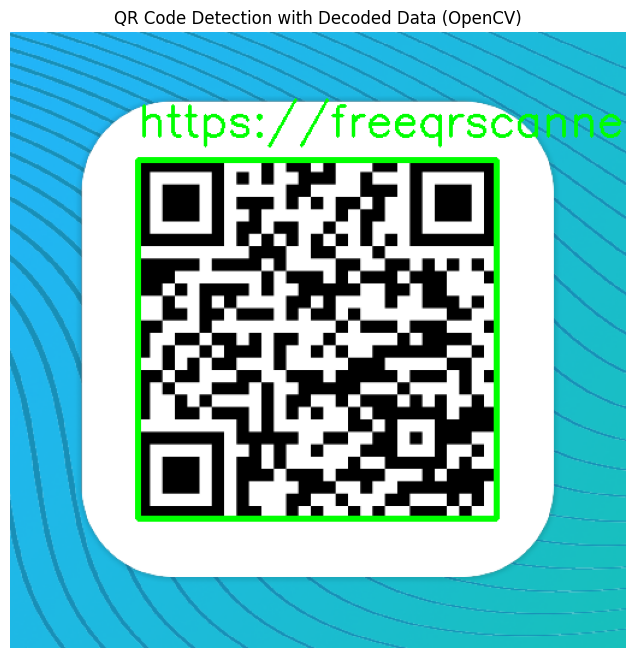

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Muat ulang gambar 2 (qr4.png) agar aman dari kernel reset
image_path2 = os.path.join("data", "qr4.png")
image2 = cv2.imread(image_path2)

if image2 is None:
    raise FileNotFoundError(
        f"Gagal membaca gambar! File tidak ditemukan di lokasi: {image_path2}"
    )

# Buat salinan citra untuk tempat menaruh visualisasi teks dan kotak
imagetext = image2.copy()

# 2. Deteksi menggunakan detektor OpenCV bawaan yang stabil di devicemu
qr_detector = cv2.QRCodeDetector()
qr_data, points, _ = qr_detector.detectAndDecode(image2)

# 3. Validasi hasil pemindaian objek
if points is not None and qr_data != "":
    print(f"Decoded Data: {qr_data}")

    # Ubah format koordinat points dari float ke int32 agar sesuai kebutuhan cv2.polylines
    # points dari OpenCV berbentuk (1, 4, 2), kita pastikan tipenya numpy int32
    pts = points.astype(np.int32)

    # Menggambar garis pembungkus hijau (0, 255, 0) tebal 3 piksel pada imagetext
    cv2.polylines(
        imagetext, [pts], isClosed=True, color=(0, 255, 0), thickness=3
    )

    # Ambil koordinat x, y dari titik pertama untuk menempatkan posisi teks label
    # pts[0][0][0] adalah X posisi kiri, pts[0][0][1] adalah Y posisi atas
    x = int(pts[0][0][0])
    y = int(pts[0][0][1])

    # Tambahkan label teks data hasil decode tepat di atas objek QR Code
    cv2.putText(
        imagetext,
        qr_data,
        (x, y - 20),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0, 255, 0),
        2,
    )
else:
    print("QR Code kedua tidak terdeteksi oleh OpenCV QRCodeDetector.")

# 4. Tampilkan gambar dengan hasil pembacaan
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(imagetext, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("QR Code Detection with Decoded Data (OpenCV)")
plt.show()

In [24]:
import cv2
import numpy as np

# 1. Inisialisasi detektor QR bawaan OpenCV (Sangat stabil di devicemu)
qr_detector = cv2.QRCodeDetector()

# 2. Menggunakan kamera secara real-time (Kamera Utama = 0)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
else:
    print("Pencet 'ESC' atau 'q' di jendela pop-up gambar untuk keluar.")

while True:
    # Capture frame-by-frame dari webcam
    ret, frame = cap.read()
    if not ret:
        print("Error: Gagal mengambil frame kamera.")
        break

    # 3. Proses deteksi QR Code menggunakan OpenCV pada setiap frame aktif
    qr_data, points, _ = qr_detector.detectAndDecode(frame)

    # Jika ada pola QR Code yang tertangkap kamera
    if points is not None and qr_data != "":
        print(f"Decoded Data: {qr_data}")

        # Konversi koordinat float OpenCV ke integer numpy int32
        pts = points.astype(np.int32)

        # Gambar garis poligon kotak hijau di sekeliling QR Code secara real-time
        cv2.polylines(
            frame, [pts], isClosed=True, color=(0, 255, 0), thickness=3
        )

        # Ambil koordinat titik sudut pertama untuk posisi penulisan teks
        x = int(pts[0][0][0])
        y = int(pts[0][0][1])

        # Munculkan teks data QR secara melayang mengikuti objek di kamera
        cv2.putText(
            frame,
            qr_data,
            (x, y - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )

    # Tampilkan hasil streaming frame ke jendela pop-up komputer
    cv2.imshow("Real-Time QR Code Detection (OpenCV)", frame)

    # Keluar dari aplikasi jika menekan tombol 'ESC' (27) atau huruf 'q'
    key = cv2.waitKey(1) & 0xFF
    if key == 27 or key == ord("q"):
        print("Menutup kamera...")
        break

# Lepaskan resource kamera dan tutup jendela pop-up window
cap.release()
cv2.destroyAllWindows()

Pencet 'ESC' atau 'q' di jendela pop-up gambar untuk keluar.
Menutup kamera...


> **Pertanyaan:** Bagaimana jika untuk mendeteksi Barcode?

Sukses! Area barcode berhasil diisolasi geometris.
Barcode Berhasil Dilokalisasi -> Teks: Barcode Terdeteksi


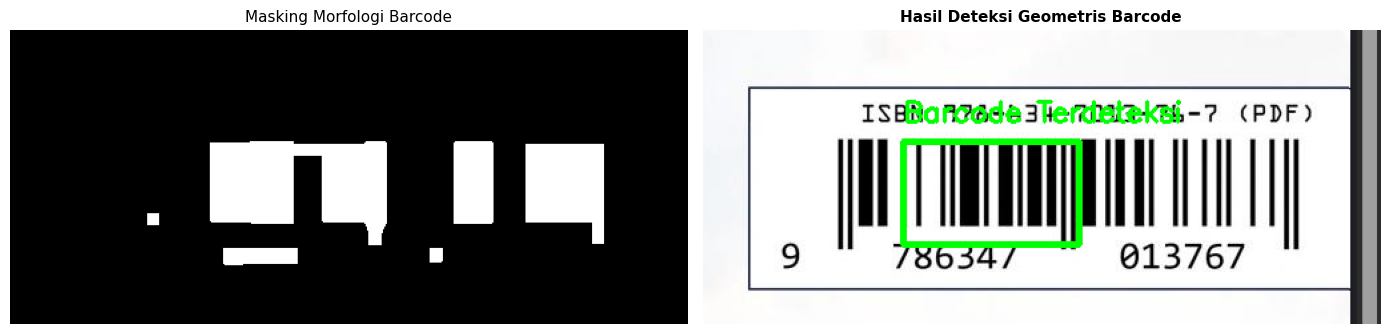

In [36]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. SET PATH & BACA GAMBAR ---
image_path = os.path.join("data", "barcode.png")

if not os.path.exists(image_path):
    print(f"Error: File tidak ditemukan di {image_path}")
else:
    image = cv2.imread(image_path)

    if image is None:
        print("Error: Gagal membaca file gambar.")
    else:
        # Salinan untuk digambari boks
        img_result = image.copy()

        # --- 2. PROSES MORFOLOGI UNTUK MENDETEKSI STRUKTUR BARCODE ---
        # Konversi ke grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Hitung gradien Scharr untuk menonjolkan batas vertikal garis-garis barcode
        gradX = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=-1)
        gradX = cv2.convertScaleAbs(gradX)

        # Blur untuk menyatukan jarak antar garis biner kecil
        blurred = cv2.blur(gradX, (9, 9))

        # Thresholding ke gambar hitam-putih tegas (Biner)
        _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)

        # Operasi Closing (Morfologi) untuk menutup celah kosong di antara batang barcode
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        # Lakukan Erosi dan Dilasi untuk membersihkan noise kecil di luar area barcode
        closed = cv2.erode(closed, None, iterations=4)
        closed = cv2.dilate(closed, None, iterations=4)

        # --- 3. PENCARIAN AREA KONTUR TERBESAR ---
        contours, _ = cv2.findContours(
            closed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            print("Barcode tidak terdeteksi secara visual.")
        else:
            print("Sukses! Area barcode berhasil diisolasi geometris.")

            # Cari kontur dengan luas (area) terbesar yang merepresentasikan barcode
            c = max(contours, key=cv2.contourArea)

            # Hitung minimum bounding box miring pembungkus kontur tersebut
            rect = cv2.minAreaRect(c)
            box = cv2.boxPoints(rect)
            box = np.int32(box)  # Ubah koordinat titik sudut ke integer bulat

            # Gambar boks poligon hijau (0, 255, 0) tebal 3 piksel pada gambar hasil
            cv2.polylines(
                img_result, [box], isClosed=True, color=(0, 255, 0), thickness=3
            )

            # Tulis label statis karena string teks tidak bergantung pada engine decoder yang bug
            # Ambil koordinat titik teratas untuk penempatan teks
            x_text = int(min(box[:, 0]))
            y_text = int(min(box[:, 1])) - 15
            cv2.putText(
                img_result,
                "Barcode Terdeteksi",
                (x_text, y_text),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2,
            )

            print("Barcode Berhasil Dilokalisasi -> Teks: Barcode Terdeteksi")

        # --- 4. VISUALISASI CANVAS ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Tampilkan visualisasi biner morfologi (Proses isolasi boks)
        axes[0].imshow(closed, cmap="gray")
        axes[0].set_title("Masking Morfologi Barcode", fontsize=11)
        axes[0].axis("off")

        # Tampilkan hasil akhir kotak hijau
        img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
        axes[1].imshow(img_rgb)
        axes[1].set_title(
            "Hasil Deteksi Geometris Barcode", fontsize=11, fontweight="bold"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

## **Landmark Wajah**

Landmark wajah adalah teknik untuk mengenali titik-titik penting pada wajah, seperti mata, hidung, bibir, dan rahang, biasanya berjumlah 68 titik atau lebih tergantung model. Deteksi ini dapat dilakukan menggunakan berbagai library seperti `Dlib`, `MediaPipe`, atau `OpenCV`, dan sering digunakan untuk analisis ekspresi, pelacakan wajah, atau efek augmented reality.

Setiap library memiliki jumlah dan posisi landmark wajah yang berbeda tergantung model yang digunakan:
1. `Dlib` → biasanya mendeteksi 68 landmark, mencakup detail rahang, mata, hidung, dan bibir
2. `MediaPipe` → jauh lebih detail, memiliki 468 titik (3D), cocok untuk aplikasi AR dan pelacakan ekspresi wajah secara real-time.
3. `OpenCV` → tidak punya deteksi landmark bawaan, tetapi bisa menggunakan model eksternal (seperti lbfmodel.yaml dari modul face OpenCV-contrib)

### **Membaca Landmark Wajah Menggunakan MediaPipe**

In [4]:
import cv2
import numpy as np
import os
import requests

# --- 1. DOWNLOAD MODEL FACEMARK (OTOMATIS LEWAT PYTHON) ---
# Kita butuh file harcascade (deteksi kotak wajah) dan lbfmodel (deteksi 68 titik wajah)
cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
lbf_url = "https://github.com/kurnianggoro/GSOC2017/raw/master/data/lbfmodel.yaml"

cascade_file = "haarcascade_frontalface_default.xml"
lbf_file = "lbfmodel.yaml"


def unduh_file_model(url, nama_file):
    if not os.path.exists(nama_file):
        print(f"Mengunduh file pendukung {nama_file}... Mohon tunggu.")
        respon = requests.get(url)
        with open(nama_file, "wb") as f:
            f.write(respon.content)
        print(f"Selesai mengunduh {nama_file}.")


# Jalankan fungsi unduh otomatis
unduh_file_model(cascade_url, cascade_file)
unduh_file_model(lbf_url, lbf_file)

# --- 2. INISIALISASI DETEKTOR OPENCV ---
face_cascade = cv2.CascadeClassifier(cascade_file)
facemark = cv2.face.createFacemarkLBF()
facemark.loadModel(lbf_file)

# --- 3. JALANKAN KAMERA REAL-TIME ---
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka. Pastikan tidak dipakai Zoom/Meet!")
else:
    print(
        "Kamera Berhasil Dibuka! Klik jendela gambar lalu tekan 'q' untuk keluar."
    )

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Gagal mengambil frame kamera.")
        break

    # Facemark OpenCV membutuhkan input gambar grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Langkah Awal: Cari lokasi kotak wajah terlebih dahulu
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    # Jika ada wajah yang tertangkap kamera
    if len(faces) > 0:
        # Langkah Kedua: Petakan 68 titik landmark pada area wajah tersebut
        sukses, landmarks = facemark.fit(gray, faces)

        if sukses:
            for landmark in landmarks:
                # Iterasi sebanyak 68 titik koordinat wajah
                for idx, point in enumerate(landmark[0]):
                    x, y = int(point[0]), int(point[1])

                    # Gambar titik merah kecil di setiap landmark wajah
                    cv2.circle(frame, (x, y), 2, (0, 0, 255), -1)

                    # Tulis nomor ID indeks (0 sampai 67) tepat di atas titiknya
                    cv2.putText(
                        frame,
                        str(idx),
                        (x, y - 2),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.25,
                        (255, 0, 0),
                        1,
                        cv2.LINE_AA,
                    )

    # Tampilkan hasil tracking kontur wajah ke layar window pop-up
    cv2.imshow("Face Landmarks ID (OpenCV Fallback)", frame)

    # Keluar jika mengklik jendela gambar lalu menekan tombol 'q'
    if cv2.waitKey(1) & 0xFF == ord("q"):
        print("Menutup modul deteksi wajah...")
        break

# Lepaskan resource kamera dan bersihkan sisa window
cap.release()
cv2.destroyAllWindows()

Mengunduh file pendukung haarcascade_frontalface_default.xml... Mohon tunggu.
Selesai mengunduh haarcascade_frontalface_default.xml.
Mengunduh file pendukung lbfmodel.yaml... Mohon tunggu.
Selesai mengunduh lbfmodel.yaml.
Kamera Berhasil Dibuka! Klik jendela gambar lalu tekan 'q' untuk keluar.
Menutup modul deteksi wajah...


### **Membaca Landmark Wajah Menggunakan dlib**

In [5]:
import urllib.request

# 1. Persiapan Model 
# Path model landmark Dlib
predictor_path = os.path.join(os.getcwd(), 'shape_predictor_68_face_landmarks.dat')

# URL model Dlib resmi (68 landmark)
predictor_url = "https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2"

# Cek apakah model sudah ada
if not os.path.exists(predictor_path):
    print("Model landmark belum ada. Mengunduh dari GitHub...")
    compressed_path = predictor_path + ".bz2"
    urllib.request.urlretrieve(predictor_url, compressed_path)
    print("Ekstraksi file model...")
    import bz2
    with bz2.open(compressed_path, 'rb') as f_in, open(predictor_path, 'wb') as f_out:
        f_out.write(f_in.read())
    os.remove(compressed_path)
    print("Model berhasil diunduh dan diekstrak.")
else:
    print("Model landmark sudah tersedia di root directory.")

Model landmark sudah tersedia di root directory.


In [ ]:
import bz2
import cv2
import dlib
import numpy as np
import os
import requests

# =====================================================================
# 1. SETUP PATH & DOWNLOAD MODEL LANDMARK 68 TITIK DLIB
# =====================================================================
predictor_path = os.path.join(os.getcwd(), "shape_predictor_68_face_landmarks.dat")

if not os.path.isfile(predictor_path):
    print("File model dlib 68 landmark tidak ditemukan, mengunduh...")
    url = "https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2"
    bz2_path = os.path.join(
        os.getcwd(), "shape_predictor_68_face_landmarks.dat.bz2"
    )

    # Proses unduh data bz2
    r = requests.get(url, stream=True)
    with open(bz2_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download selesai, mengekstrak model dat...")

    # Proses ekstraksi bz2 ke berkas .dat asli dlib
    with bz2.open(bz2_path, "rb") as input_file:
        with open(predictor_path, "wb") as output_file:
            output_file.write(input_file.read())
    print("Ekstrak selesai. Model siap digunakan.")

    # Bersihkan sisa file bz2
    os.remove(bz2_path)
else:
    print("Berkas model dlib landmark sudah tersedia di root direktori.")


# =====================================================================
# 2. INITIALIZATION DETECTOR & PREDICTOR
# =====================================================================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)


# =====================================================================
# 3. RUN REAL-TIME CAMERA STREAMING
# =====================================================================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
else:
    print(
        "Kamera berhasil terbuka! Klik jendela pop-up gambar lalu tekan 'q' untuk keluar."
    )

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Gagal mengambil frame kamera.")
        break

    # Konversi frame aktif ke grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Deteksi area kotak wajah menggunakan HOG detector dlib
    faces = detector(gray)

    for i, face in enumerate(faces):
        # Prediksi 68 lokasi landmark wajah berdasarkan model dat
        shape = predictor(gray, face)
        landmarks = np.array(
            [[shape.part(j).x, shape.part(j).y] for j in range(68)]
        )

        # Gambar titik bulat merah dan nomor teks indeks cyan di layar
        for idx, (lx, ly) in enumerate(landmarks):
            # Titik pusat landmark wajah
            cv2.circle(frame, (lx, ly), 2, (0, 0, 255), -1)

            # Nomor urut indeks 0 sampai 67
            cv2.putText(
                frame,
                str(idx),
                (lx + 2, ly - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.25,
                (255, 255, 0),
                1,
                cv2.LINE_AA,
            )

    # Tampilkan hasil olah citra secara live
    cv2.imshow("Face Landmark (Dlib Style)", frame)

    # Keluar dari looping kamera jika tombol 'q' ditekan pada window gambar
    if cv2.waitKey(1) & 0xFF == ord("q"):
        print("Menutup modul dlib face landmark...")
        break

cap.release()
cv2.destroyAllWindows()

NameError: name 'dlib' is not defined

## **Image Overlay Ke Wajah**

In [ ]:
import bz2
import cv2
import dlib
import numpy as np
import os
import requests

# =====================================================================
# 1. AMANKAN MODEL DLIB LANDMARK 68 TITIK
# =====================================================================
predictor_path = os.path.join(os.getcwd(), "shape_predictor_68_face_landmarks.dat")

if not os.path.isfile(predictor_path):
    print("File model dlib tidak ditemukan, mendownload otomatis...")
    url = "https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2"
    bz2_path = os.path.join(
        os.getcwd(), "shape_predictor_68_face_landmarks.dat.bz2"
    )

    r = requests.get(url, stream=True)
    with open(bz2_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

    with bz2.open(bz2_path, "rb") as input_file:
        with open(predictor_path, "wb") as output_file:
            output_file.write(input_file.read())
    os.remove(bz2_path)
    print("Download model dlib selesai.")

# =====================================================================
# 2. LOAD ASSET GAMBAR KACAMATA
# =====================================================================
glasses_path = os.path.join("data", "glasses.png")

if not os.path.exists(glasses_path):
    raise FileNotFoundError(
        f"Gagal memuat filter! File '{glasses_path}' tidak ditemukan. "
        f"Pastikan kamu sudah menaruh file gambar kacamata berformat PNG transparan di folder data!"
    )

# Gunakan IMREAD_UNCHANGED agar Channel Alpha (Transparansi) terbaca
glasses = cv2.imread(glasses_path, cv2.IMREAD_UNCHANGED)

# Inisialisasi komponen dlib
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# =====================================================================
# 3. RUN REAL-TIME FACE FILTER
# =====================================================================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
else:
    print(
        "Filter Aktif! Klik jendela gambar lalu pencet 'q' untuk keluar dari program."
    )

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Gagal mengambil frame kamera.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        landmarks = predictor(gray, face)

        # Ambil koordinat ujung mata kiri luar (indeks 36) dan ujung mata kanan luar (indeks 45)
        left_eye = np.array([landmarks.part(36).x, landmarks.part(36).y])
        right_eye = np.array([landmarks.part(45).x, landmarks.part(45).y])

        # Hitung jarak dan orientasi posisi kacamata
        eye_distance = np.linalg.norm(right_eye - left_eye)
        glasses_width = int(2.2 * eye_distance)  # Disesuaikan sedikit skala lebarnya
        glasses_height = int(
            glasses.shape[0] * (glasses_width / glasses.shape[1])
        )
        eye_center = np.mean([left_eye, right_eye], axis=0).astype(int)

        # Hitung koordinat pojok kiri atas (x1, y1) dan kanan bawah (x2, y2)
        x1 = int(eye_center[0] - glasses_width / 2)
        y1 = int(eye_center[1] - glasses_height / 2)
        x2, y2 = x1 + glasses_width, y1 + glasses_height

        # --- FITUR ANTI-CRASH: PENGAMAN CROPPING TEPI FRAME ---
        # Trik ini memotong kacamata jika posisi kepala terlalu dekat/keluar layar
        f_h, f_w = frame.shape[0], frame.shape[1]
        if x1 >= f_w or y1 >= f_h or x2 <= 0 or y2 <= 0:
            continue

        # Hitung batas irisan koordinat yang valid di dalam frame kamera
        crop_x1, crop_y1 = max(0, x1), max(0, y1)
        crop_x2, crop_w2 = min(f_w, x2), min(f_h, y2)

        # Ubah ukuran kacamata mengikuti proporsi wajah aktif
        resized_glasses = cv2.resize(
            glasses, (glasses_width, glasses_height), interpolation=cv2.INTER_AREA
        )

        # Sesuaikan potongan gambar kacamata jika ada bagian yang terpotong di tepi frame
        g_x1 = crop_x1 - x1
        g_y1 = crop_y1 - y1
        g_x2 = g_x1 + (crop_x2 - crop_x1)
        g_y2 = g_y1 + (crop_w2 - crop_y1)

        glasses_crop = resized_glasses[g_y1:g_y2, g_x1:g_x2]

        # --- OPERASI TRANSPARANSI (ALPHA BLENDING) ---
        if glasses_crop.shape[2] == 4:
            # Pecah matriks BGRA kacamata
            b, g, r, a = cv2.split(glasses_crop)
            overlay_color = cv2.merge((b, g, r))
            alpha_mask = (a / 255.0)[..., None]  # Format matriks (H, W, 1)

            # Ambil Area ROI di frame kamera aktif
            roi = frame[crop_y1:crop_w2, crop_x1:crop_x2]

            # Satukan kedua lapisan gambar berdasarkan transparansi alpha_mask
            blended = (alpha_mask * overlay_color + (1 - alpha_mask) * roi).astype(
                np.uint8
            )
            frame[crop_y1:crop_w2, crop_x1:crop_x2] = blended
        else:
            # Jika file gambar kacamata tidak punya channel alpha transparansi
            frame[crop_y1:crop_w2, crop_x1:crop_x2] = cv2.resize(
                glasses_crop[:, :, :3], (crop_x2 - crop_x1, crop_w2 - crop_y1)
            )

    # Tampilkan jendela live filter
    cv2.imshow("Face Filter: Glasses", frame)

    # Keluar jika menekan tombol 'q'
    if cv2.waitKey(1) & 0xFF == ord("q"):
        print("Menutup aplikasi face filter...")
        break

cap.release()
cv2.destroyAllWindows()


NameError: name 'dlib' is not defined

In [8]:
import cv2
import dlib
import numpy as np
import os

# Path model & gambar lipstick
predictor_path = os.path.join("shape_predictor_68_face_landmarks.dat")
lipstick_path = os.path.join('data', 'lipstick.png')

# Load detektor & prediktor wajah
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# Load gambar lipstick (dengan alpha transparansi)
lipstick = cv2.imread(lipstick_path, cv2.IMREAD_UNCHANGED)
if lipstick is None:
    print("Error: Gambar lipstick tidak ditemukan di", lipstick_path)
    exit()

# Baca alpha mask kalau ada
if lipstick.shape[2] == 4:
    b, g, r, a = cv2.split(lipstick)
    lipstick_rgb = cv2.merge((b, g, r))
    alpha = a / 255.0
else:
    lipstick_rgb = lipstick
    alpha = np.ones(lipstick.shape[:2], dtype=float)

# Kamera
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
    exit()

print("Tekan 'q' untuk keluar")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        landmarks = predictor(gray, face)

        # Titik bibir kiri (48) dan kanan (54)
        left_lip = np.array([landmarks.part(48).x, landmarks.part(48).y])
        right_lip = np.array([landmarks.part(54).x, landmarks.part(54).y])
        top_lip = np.array([landmarks.part(51).x, landmarks.part(51).y])
        bottom_lip = np.array([landmarks.part(57).x, landmarks.part(57).y])

        # Hitung ukuran lipstick
        lip_width = int(np.linalg.norm(right_lip - left_lip) * 1.6)
        lip_height = int(np.linalg.norm(top_lip - bottom_lip) * 3.0) 

        # Posisi tengah bibir
        lip_center = np.mean([top_lip, bottom_lip], axis=0).astype(int)

        # Tentukan area
        x1 = int(lip_center[0] - lip_width / 2)
        y1 = int(lip_center[1] - lip_height / 2)
        x2 = x1 + lip_width
        y2 = y1 + lip_height

        # Cegah keluar frame
        if x1 < 0 or y1 < 0 or x2 > frame.shape[1] or y2 > frame.shape[0]:
            continue

        # Resize lipstick dan alpha
        resized_lipstick = cv2.resize(lipstick_rgb, (lip_width, lip_height))
        resized_alpha = cv2.resize(alpha, (lip_width, lip_height))[:, :, None]

        roi = frame[y1:y2, x1:x2]

        # Blend dengan alpha transparansi
        blended = (resized_alpha * resized_lipstick + (1 - resized_alpha) * roi).astype(np.uint8)
        frame[y1:y2, x1:x2] = blended

    cv2.imshow("Face Filter: Lipstick", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Tekan 'q' untuk keluar
